In [5]:
from itertools import combinations
import os
import copy

import hydra
import pandas
import torch
from torch.nn.functional import cosine_similarity

from src.models import deploy
from src.utils import clean_state_dict
from src.utils.factory import create_model_cls

methods = ['Add', 'Sub']
architectures = ['33', '333', '3333', '33333']
weight_name = 'model_best.pth.tar'
weight_root = 'weights'


def load_checkpoint(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    state_dict = clean_state_dict(checkpoint['state_dict'])
    model.load_state_dict(state_dict)

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Width-wise similarity

In [14]:
@torch.no_grad()
def main(method, architecture):
    with hydra.initialize(config_path='configs', version_base='1.3'):
        cfg = hydra.compose(config_name='sub_cifar')
        cfg.local_rank = 0

    connectivity = f'{method}{architecture}'
    model_name = f'resnet18_{connectivity}'
    model = create_model_cls(
        model_name,
        in_channels=cfg.dataset.in_channels,
        num_classes=cfg.dataset.num_classes,
        stem_type=cfg.dataset.name,
    )
    load_checkpoint(model, os.path.join(weight_root, 'cifar100', 'multi', model_name + '.pth.tar'))
    model.eval()

    combination_range = len(architecture)
    df = pandas.DataFrame()
    for name, module in model.named_modules():
        if 'downsample' in name:
            continue
        if isinstance(module, torch.nn.ModuleList):
            kernels = list()
            similarity = list()
            for m in module:
                weight = m[0].weight / m[0].weight.norm(p=2, dim=0, keepdim=True)
                kernels.append(weight)

            for i, j in combinations(range(combination_range), 2):
                similarity.append(cosine_similarity(kernels[i], kernels[j]).mean())

            score = (sum(similarity) / len(similarity)).item()
            df = pandas.concat([df, pandas.DataFrame([[name, score]])])

    # print(df)
    # print(df.describe())    
    return df.mean(numeric_only=True)[1]


df = pandas.DataFrame()
for m in methods:
    for a in architectures:
        res = main(m, a)
        df[f'{m}{a}'] = [res]

width_wise_result = df.T
# df.to_csv('analysis_similarity_width.csv')

No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetSub model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetSub model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetSub model. Using a default. Please

In [7]:
@torch.no_grad()
def main(method, architecture):
    with hydra.initialize(config_path='configs', version_base='1.3'):
        cfg = hydra.compose(config_name='sub_cifar')
        cfg.local_rank = 0

    connectivity = f'{method}{architecture}'
    model_name = f'resnet18_{connectivity}'
    model = create_model_cls(
        model_name,
        in_channels=cfg.dataset.in_channels,
        num_classes=cfg.dataset.num_classes,
        stem_type=cfg.dataset.name,
    )
    load_checkpoint(model, os.path.join(weight_root, 'cifar100', 'multi', model_name + '.pth.tar'))
    model.eval()

    combination_range = len(architecture)
    similarity = list()
    for name, module in model.named_modules():
        if 'downsample' in name:
            continue
        if isinstance(module, torch.nn.ModuleList):
            kernels = list()
            for m in module:
                weight = m[0].weight / m[0].weight.norm(p=2, dim=0, keepdim=True)
                kernels.append(weight)

            for i, j in combinations(range(combination_range), 2):
                similarity.append(cosine_similarity(kernels[i], kernels[j]).mean().item())

    return similarity


width_wise_result = list()
for m in methods:
    for a in architectures:
        width_wise_result.append(main(m, a))

# print(width_wise_result)
print(len(width_wise_result))
print(len(width_wise_result[0]))
# df.to_csv('analysis_similarity_width.csv')

No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetSub model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetSub model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetSub model. Using a default. Please

8
16


### Depth-wise Similarity

In [8]:
@torch.no_grad()
def main(method, architecture):
    with hydra.initialize(config_path='configs', version_base='1.3'):
        cfg = hydra.compose(config_name='sub_cifar')
        cfg.local_rank = 0

    connectivity = f'{method}{architecture}'
    model_name = f'resnet18_{connectivity}'
    model = create_model_cls(
        model_name,
        in_channels=cfg.dataset.in_channels,
        num_classes=cfg.dataset.num_classes,
        stem_type=cfg.dataset.name,
    )
    load_checkpoint(model, os.path.join(weight_root, 'cifar100', 'multi', model_name + '.pth.tar'))
    model.eval()
    deploy(model)

    stem = torch.nn.Sequential(*list(model.children())[:4])
    modules = list(model.children())[4:8]
    layers = list()
    for x in modules:
        layers += list(x.children())

    input_feature = stem(torch.rand(1, 3, 32, 32))
    pool = torch.nn.AdaptiveAvgPool3d((64, 16, 16))
    features = list()

    for i in range(len(layers)):
        out = copy.deepcopy(input_feature)
        for j, layer in enumerate(layers):
            out = layer(out)
            if j == i:
                _out = pool(out)
                _out = _out / _out.norm(p=2, dim=1, keepdim=True)
                features.append(_out)
                break

    similarity = list()
    for f in features:
        similarity.append(cosine_similarity(features[0], f))
    return similarity


depth_wise_result = list()
for m in methods:
    for a in architectures:
        depth_wise_result.append(main(m, a))

No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetAdd model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetSub model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetSub model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.
No pretrained configuration specified for ResNetSub model. Using a default. Please

### Graph

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

import copy
from torch import nn
import scienceplots


pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Custom Color
g20_categorical = ["#3366cc", "#dc3912", "#ff9900", "#109618", "#990099", "#0099c6", "#dd4477", "#66aa00", "#b82e2e",
                   "#316395", "#994499", "#22aa99", "#aaaa11", "#6633cc", "#e67300", "#8b0707", "#651067", "#329262",
                   "#5574a6", "#3b3eac"]
science = ['#0C5DA5', '#FF2C00', '#FF9500', '#00B945', '#845B97', '#474747', '#9e9e9e']

# Settings
plt.style.use(['science', 'ieee'])
# plt.figure(figsize=(4, 5), dpi=300)
# Custom Settings
plt.rcParams.update({
    'axes.prop_cycle': "cycler('color', ['#0C5DA5', '#FF2C00', '#FF9500','#00B945', '#845B97', '#474747', '#9e9e9e'])",
    'xtick.major.size': 2.0,
    'ytick.major.size': 2.0,
    'xtick.minor.visible': False,
    'xtick.top': False,
    'xtick.bottom': True,
    'ytick.minor.visible': False,
    'ytick.right': False,
    'figure.edgecolor': '#0e1111',
    'axes.axisbelow': True,
    'svg.fonttype': 'none',
    'text.usetex': False,
    'font.family': ['sans-serif']
})
origin_rc_param = copy.deepcopy(plt.rcParams)

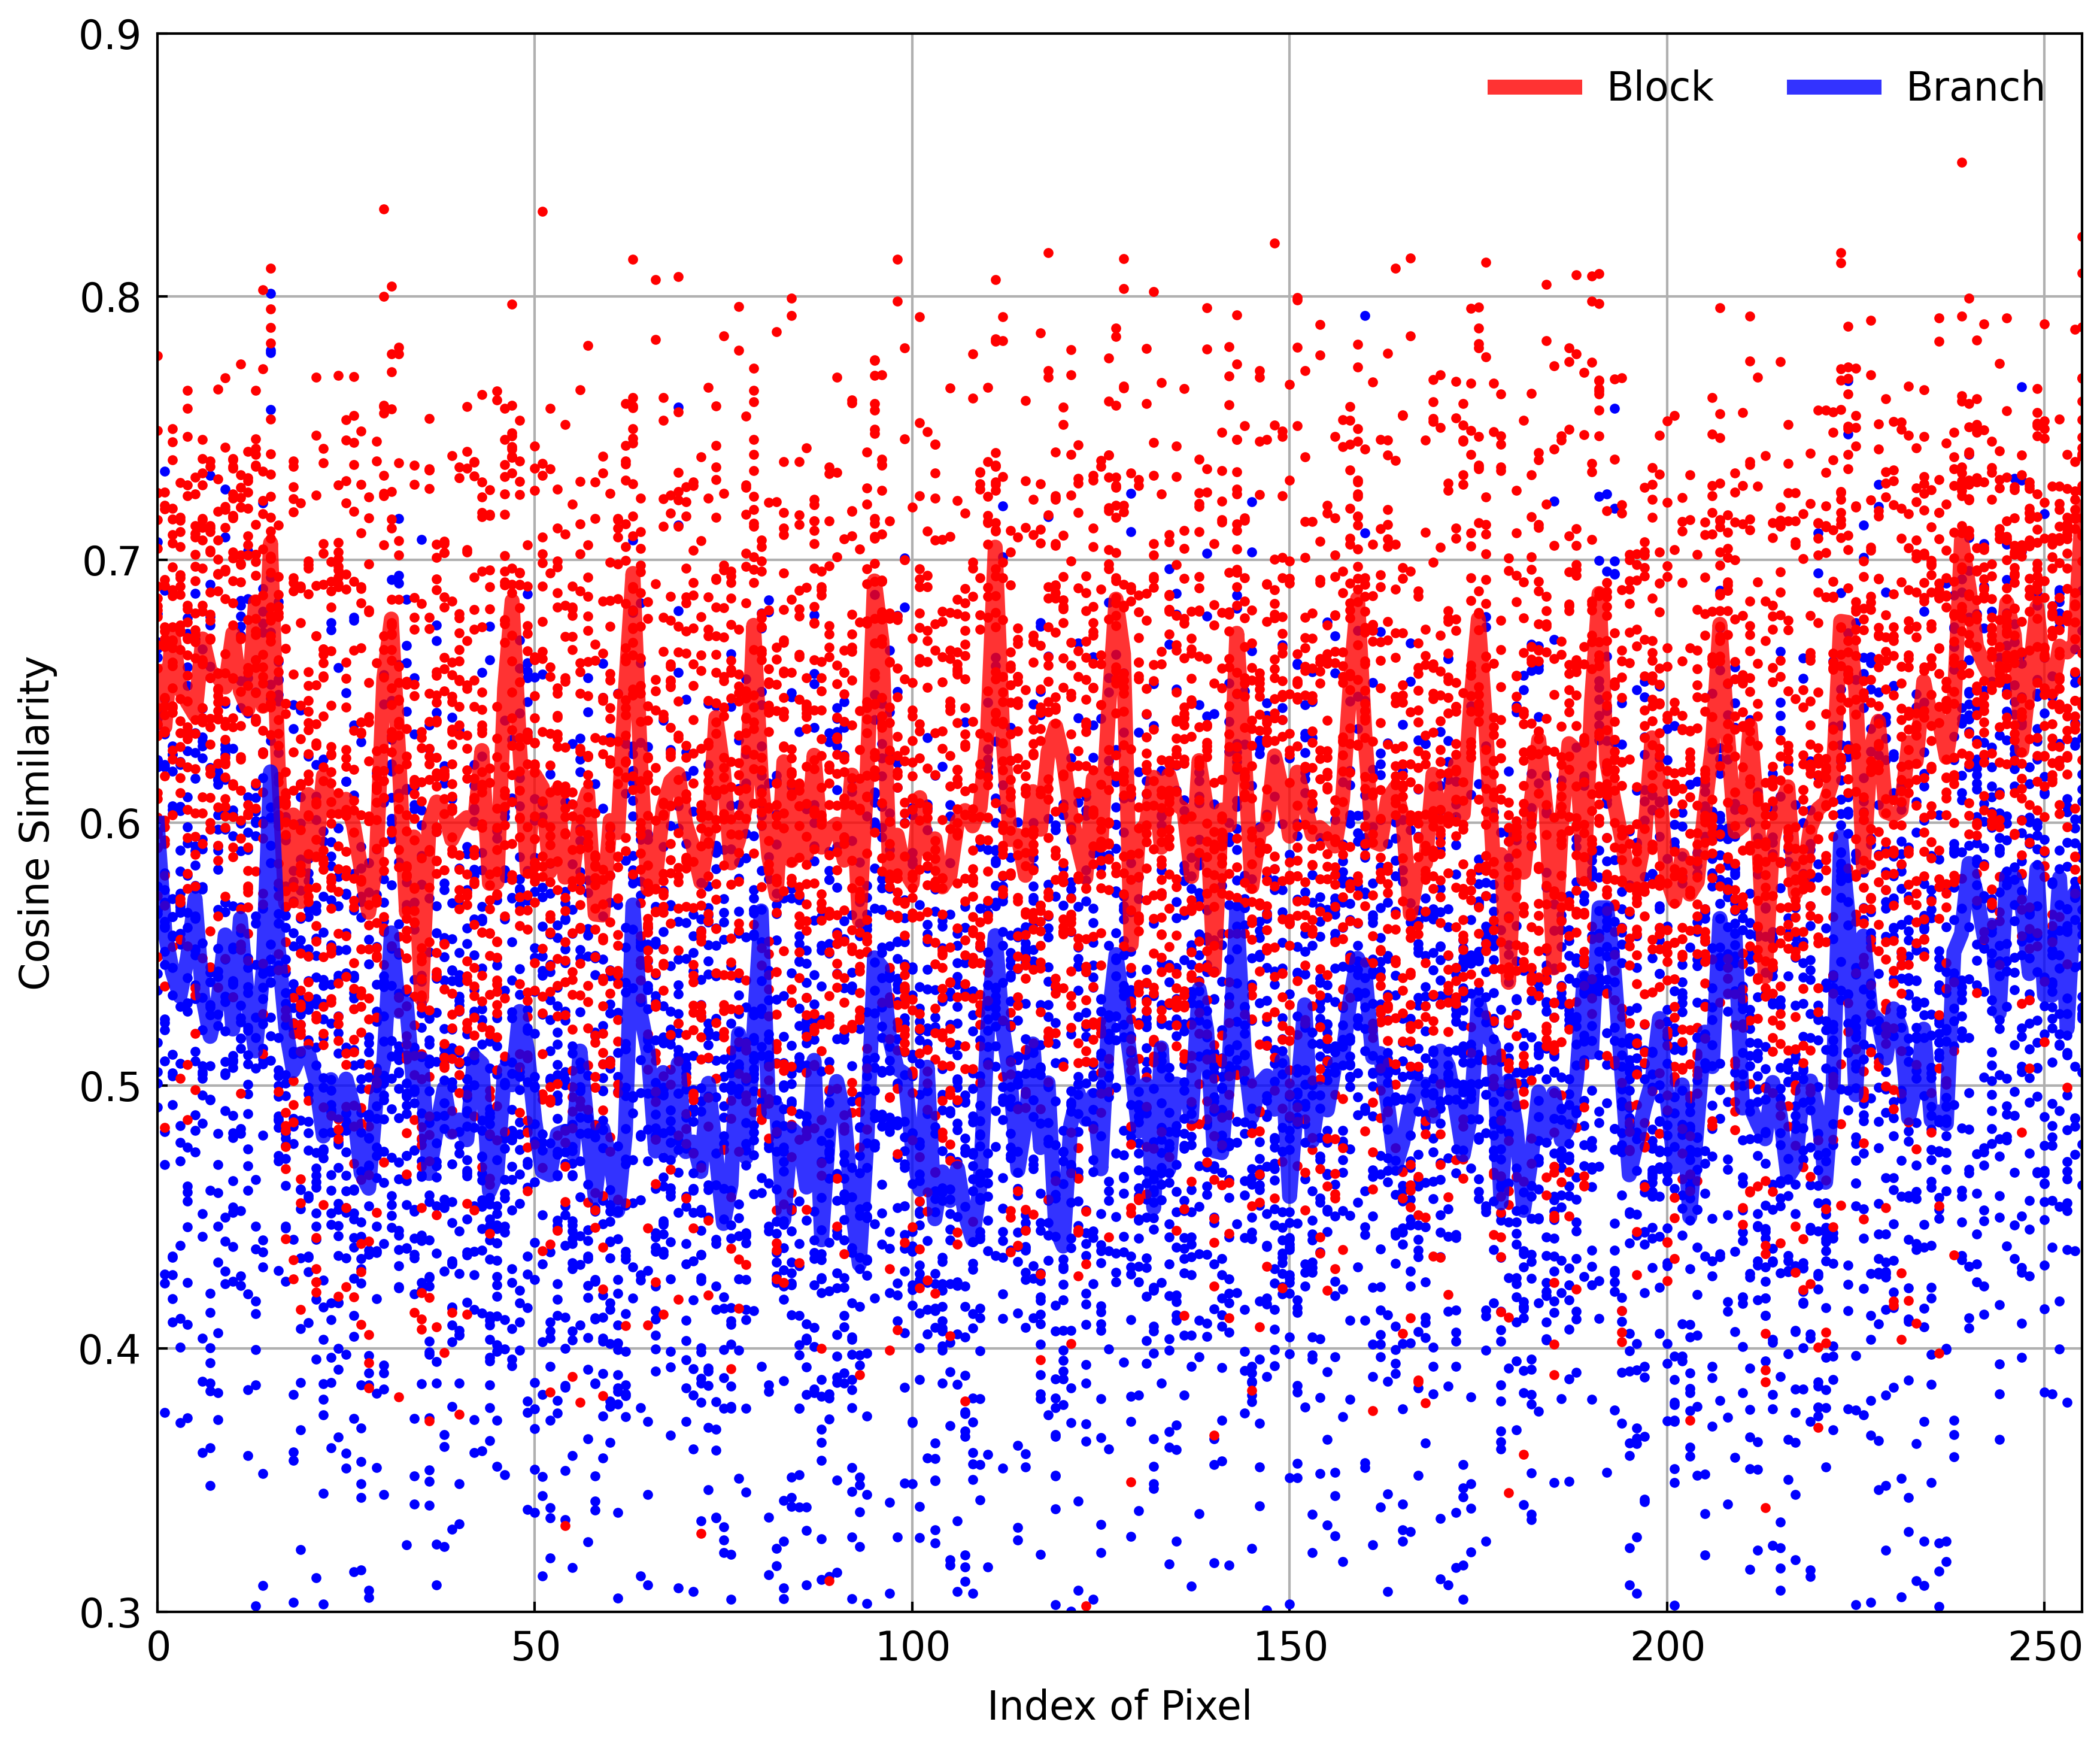

In [12]:
# Depth-wise Similarity
flatten = nn.Flatten()

fig = plt.figure(figsize=(6, 5))

size = depth_wise_result[0][0].size(1) ** 2
add_sum = np.zeros(size)
sub_sum = np.zeros(size)

for i in range(4, 8):
    for j in range(2, 8):
        x = flatten(depth_wise_result[i][j]).tolist()[0]
        sub_sum += np.array(x)
        plt.scatter(range(len(x)), x, s=1, color='b', alpha=1.0)

for i in range(0, 4):
    for j in range(2, 8):
        x = flatten(depth_wise_result[i][j]).tolist()[0]
        add_sum += np.array(x)
        plt.scatter(range(len(x)), x, s=1, color='r', alpha=1.0)

add_sum /= 24
sub_sum /= 24

plt.plot(range(len(add_sum)), add_sum, '-r', linewidth=3, alpha=0.8, label='Block')
plt.plot(range(len(sub_sum)), sub_sum, '-b', linewidth=3, alpha=0.8, label='Branch')

plt.ylim(0.3, 0.9)
plt.xlim(0, 255)
plt.xlabel('Index of Pixel')
plt.ylabel('Cosine Similarity')
plt.grid(True)

plt.legend(loc='upper right', ncols=2)

fig.tight_layout()
plt.savefig(f'assets/depth_wise_similarity.svg', dpi=500, format='svg')
plt.show()

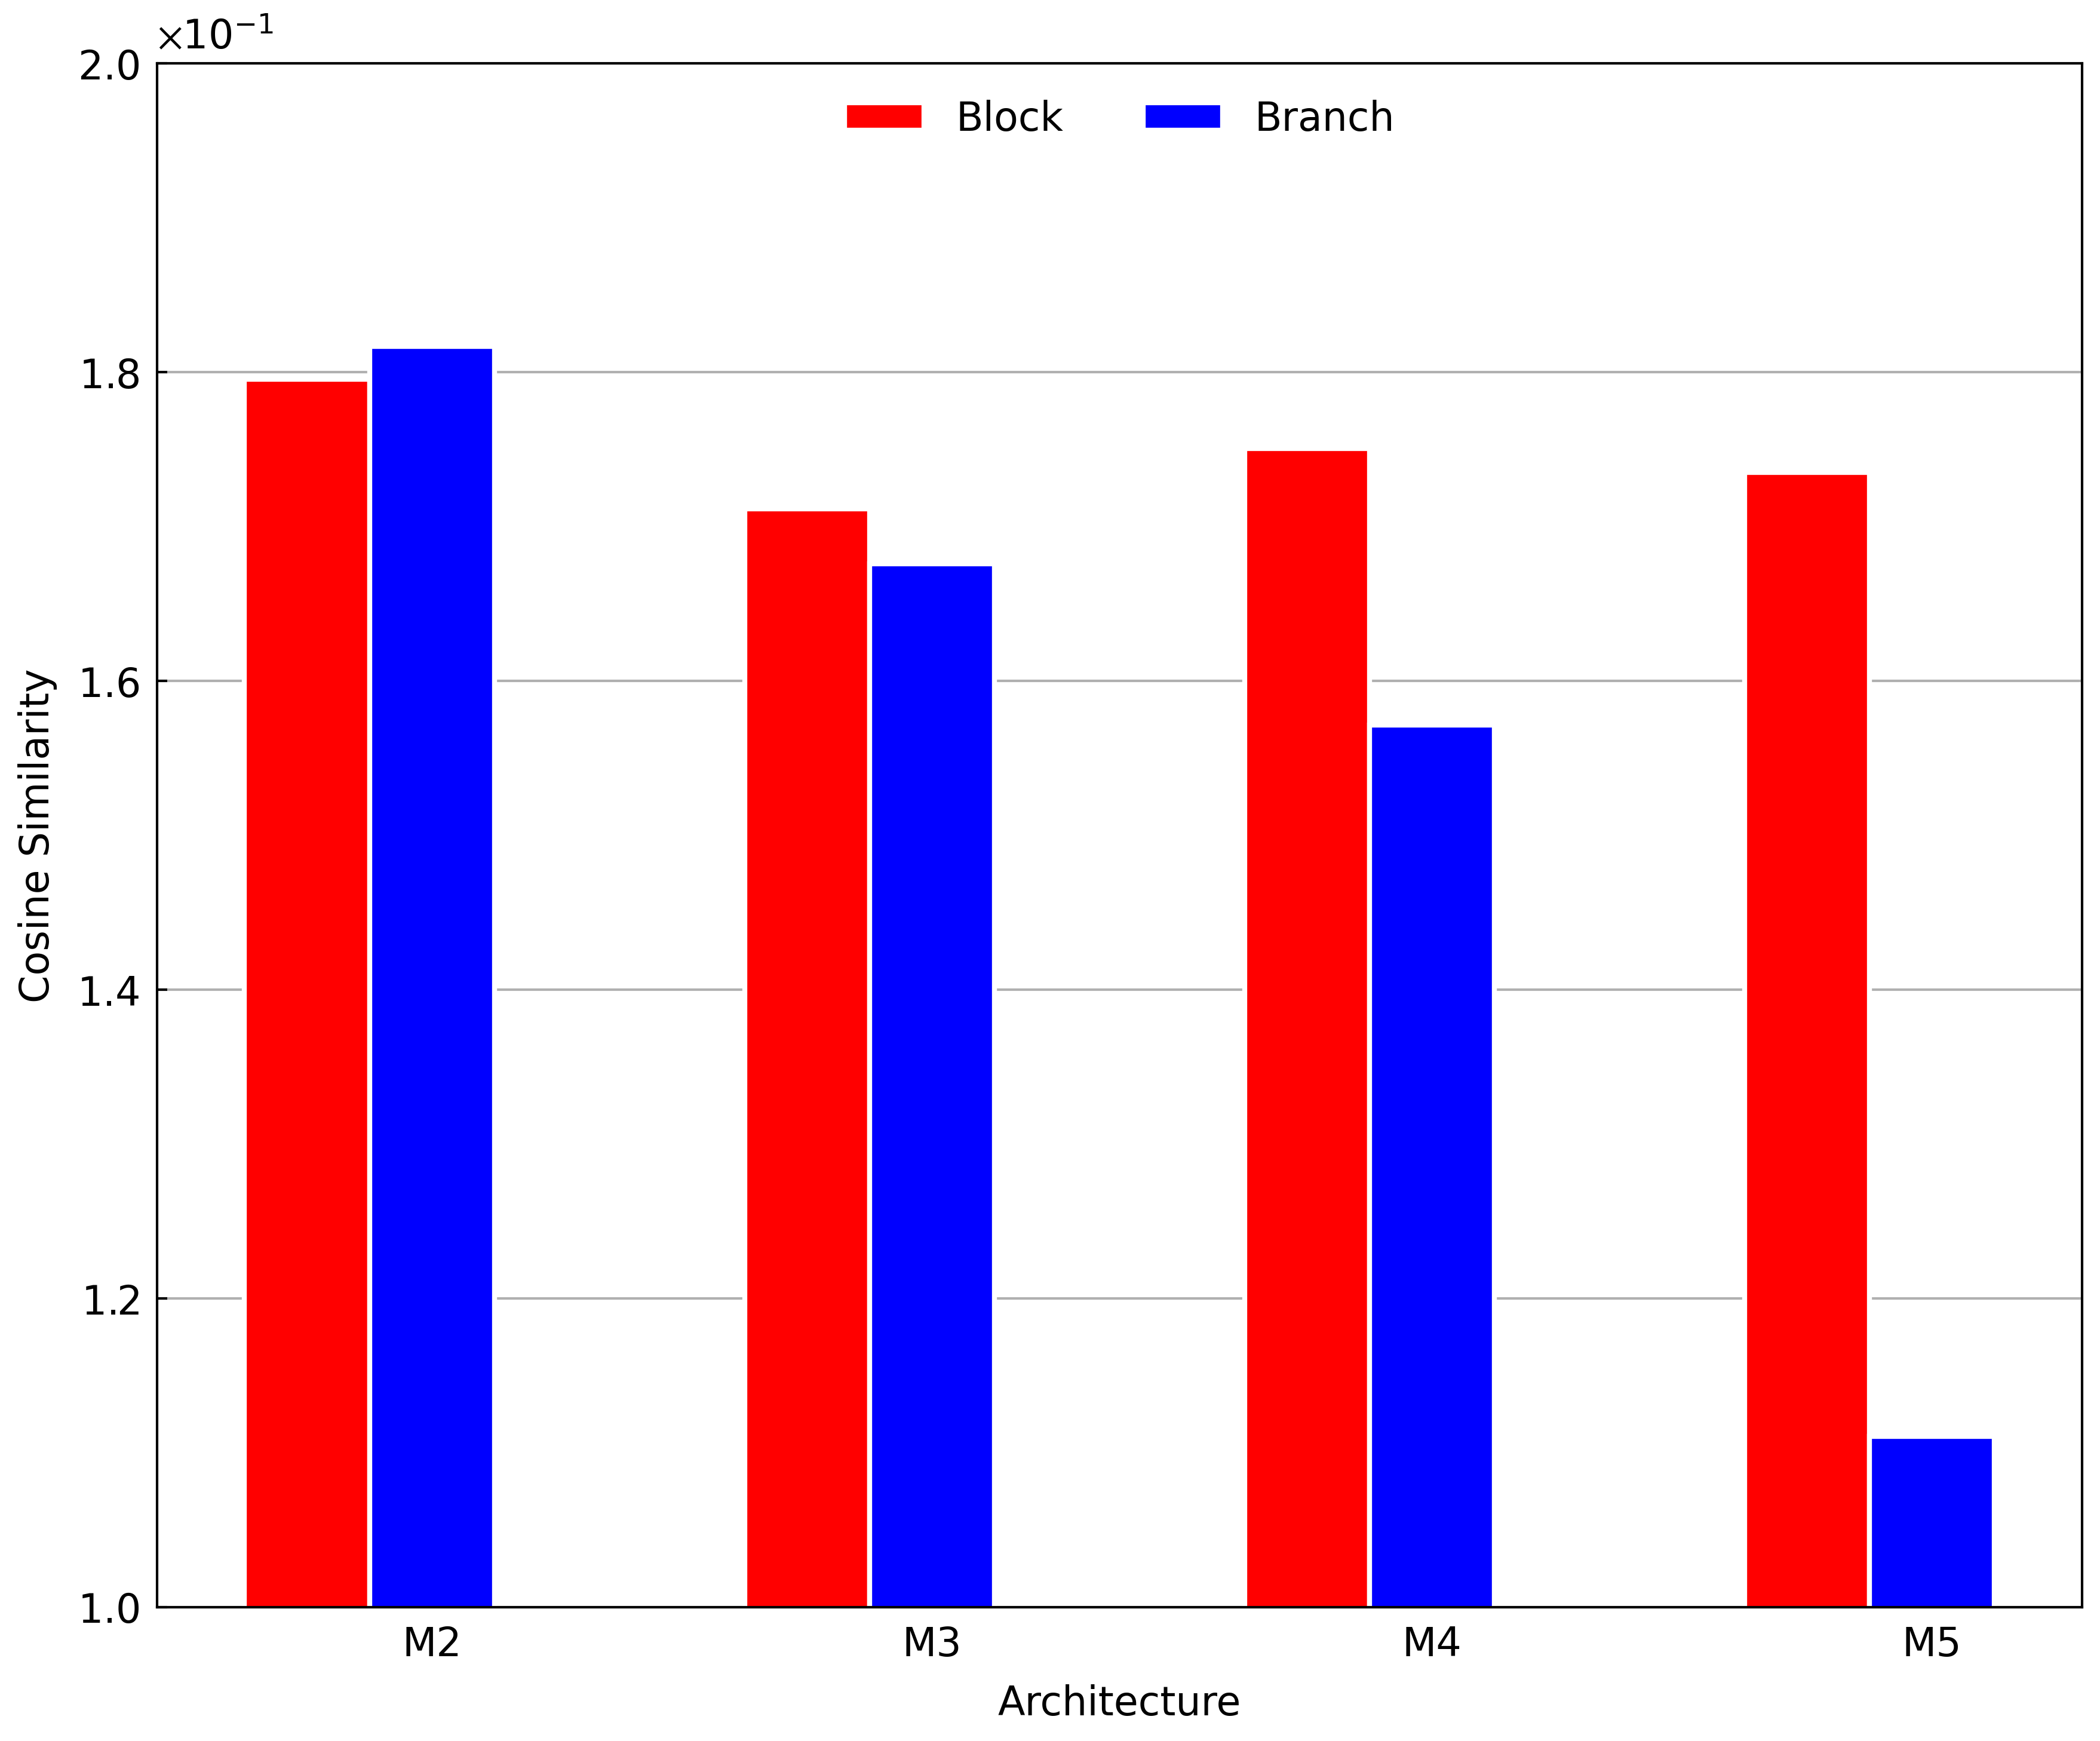

In [18]:
# name = width_wise_result.index.tolist()
value = width_wise_result[0]

fig, ax = plt.subplots(figsize=(6, 5), layout='constrained')

archi = ['M2', 'M3', 'M4', 'M5']
similarity = {
    'Block': value[:4],
    'Branch': value[4:],
}

x = np.arange(len(archi))
multiplier = 0
width = 0.25
hatches = ['', '']
color = ['r','b']
for i, (connectivity, sim) in enumerate(similarity.items()):
    offset = width * multiplier
    rects = plt.bar(x + offset, sim, width, label=connectivity, hatch=hatches[i], color=color[i], edgecolor='w')
    multiplier += 1

plt.xticks(x + width, archi)
plt.yticks([0.10, 0.12, 0.14, 0.16, 0.18, 0.2])
plt.ylim(0.1, 0.2)
plt.ylabel('Cosine Similarity')
plt.xlabel('Architecture')
plt.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useMathText=True)
plt.grid(True, axis='y')

plt.legend(loc='upper center', ncols=2)

fig.tight_layout()
plt.savefig(f'assets/width_wise_similarity.svg', dpi=500)
plt.show()
